# Proyek Analisis Data: E-Commerce Public
- **Nama:** Raihan Ikram Maulana
- **Email:** raihanmaulana994@gmail.com
- **ID Dicoding:** raihanikram

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk apa yang memberikan kontribusi revenue terbesar berdasarkan data transaksi yang tersedia selama periode analisis, dan bagaimana distribusi kontribusi revenue antar kategori tersebut?
- **Pertanyaan 2:** Bagaimana segmentasi pelanggan berdasarkan Recency, Frequency, dan Monetary (RFM) selama periode transaksi yang tersedia, serta bagaimana kontribusi masing-masing segmen terhadap total revenue?

## Import Semua Packages/Library yang Digunakan

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [71]:
customers = pd.read_csv("customers_dataset.csv")
orders = pd.read_csv("orders_dataset.csv")
order_items = pd.read_csv("order_items_dataset.csv")
products = pd.read_csv("products_dataset.csv")
payments = pd.read_csv("order_payments_dataset.csv")

**Insight:**

Pada tahap ini dilakukan pengumpulan beberapa dataset yang relevan dengan kebutuhan analisis, yaitu data pelanggan, pesanan, item pesanan, produk, dan pembayaran.

Dataset yang dipilih merupakan data yang berkaitan langsung dengan transaksi dan pelanggan, sehingga dapat digunakan untuk menganalisis revenue serta segmentasi pelanggan.

Dataset lain yang tidak digunakan tidak memiliki hubungan langsung dengan tujuan analisis.

### Assessing Data

####  Identifying Data Quality Issues

In [72]:
# Cek Missing value
orders.isna().sum()


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [73]:
# Cek Duplicate
orders.duplicated().sum()

np.int64(0)

In [74]:
# Cek Deskripsi Statistik
orders.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [75]:
# Cek Value Unik
orders['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [76]:
# Cek Tipe Data
orders.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,object
order_approved_at,object
order_delivered_carrier_date,object
order_delivered_customer_date,object
order_estimated_delivery_date,object


**Steps to Take:**
- Melakukan cek Missing Value
- Melakukan cek data yang duplikat

**Insight:** (Opsional)


Berdasarkan proses assessing data, ditemukan beberapa permasalahan sebagai berikut:

- Missing Value:
Terdapat nilai kosong pada beberapa kolom, khususnya pada `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date`. Hal ini menunjukkan bahwa tidak semua pesanan memiliki informasi lengkap terkait proses pengiriman.

- Duplicate Data:
Tidak ditemukan data duplikat pada dataset, sehingga tidak diperlukan penanganan lebih lanjut untuk duplikasi.

- Inconsistent Value:
Kolom `order_status` memiliki beberapa variasi nilai seperti delivered, shipped, canceled, dan lainnya. Hal ini menunjukkan bahwa data mencakup berbagai kondisi pesanan, sehingga perlu dilakukan filtering untuk fokus pada analisis tertentu (misalnya hanya pesanan yang telah selesai/delivered).

- Invalid / Inaccurate Value:
Beberapa kolom waktu seperti `order_purchase_timestamp` dan kolom tanggal lainnya masih bertipe object (string), sehingga perlu dikonversi ke tipe datetime agar dapat digunakan dalam analisis berbasis waktu.

- Outlier:
Berdasarkan karakteristik data transaksi, kemungkinan terdapat nilai ekstrem pada beberapa variabel seperti waktu pengiriman atau nilai transaksi, sehingga perlu diperhatikan dalam analisis lanjutan.



### Cleaning Data

#### Fixing "Assesing" problem

In [77]:
orders_clean = orders[orders['order_status'] == 'delivered'].copy() # memfilter data dengan status 'delivered'

In [78]:
orders_clean = orders_clean.dropna(subset=[
    'order_delivered_customer_date',
    'order_approved_at',
    'order_delivered_carrier_date'
])

In [79]:
# Convert ke datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col])

In [80]:
# cek missing value
orders_clean.isna().sum()


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0


In [81]:
#Cek duplicate
orders_clean.duplicated().sum()


np.int64(0)

In [82]:
orders_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96455 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96455 non-null  object        
 1   customer_id                    96455 non-null  object        
 2   order_status                   96455 non-null  object        
 3   order_purchase_timestamp       96455 non-null  datetime64[ns]
 4   order_approved_at              96455 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96455 non-null  datetime64[ns]
 6   order_delivered_customer_date  96455 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96455 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB


**Insight:** (Opsional)
Data Cleaning

Pada tahap ini dilakukan beberapa proses pembersihan data berdasarkan hasil assessing sebelumnya.

- Data difilter hanya untuk pesanan dengan status "delivered" agar analisis difokuskan pada transaksi yang telah selesai.

- Nilai kosong pada beberapa kolom penting seperti `order_delivered_customer_date`, `order_approved_at`, dan `order_delivered_carrier_date` dihapus karena dapat memengaruhi akurasi analisis.

- Kolom yang berkaitan dengan waktu dikonversi ke tipe datetime agar dapat digunakan dalam analisis berbasis waktu.

Insight

Setelah proses cleaning, dataset menjadi lebih konsisten dan siap digunakan untuk analisis lebih lanjut. Data yang digunakan hanya mencakup transaksi yang valid dan memiliki informasi lengkap.

## Exploratory Data Analysis (EDA)

In [83]:
# Beberapa dataset digabungkan untuk membentuk dataset utama yang lebih lengkap, sehingga dapat digunakan untuk analisis yang lebih mendalam.
df = orders_clean.merge(order_items, on="order_id") \
                 .merge(products, on="product_id") \
                 .merge(payments, on="order_id") \
                 .merge(customers, on="customer_id")

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,8.0,13.0,1,credit_card,1,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,8.0,13.0,3,voucher,1,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,8.0,13.0,2,voucher,1,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,13.0,19.0,1,boleto,1,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,19.0,21.0,1,credit_card,3,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [84]:
df_analysis = df[[
    'product_category_name',
    'price',
    'freight_value',
    'order_purchase_timestamp',
    'customer_id'
]].copy()

In [85]:
df_analysis['revenue'] = df_analysis['price'] + df_analysis['freight_value'] #menambahkan revenue
df_analysis['revenue'].describe()

,revenue
count,115011.000000
mean,140.077832
std,190.104999
min,6.080000
25%,55.235000
50%,91.880000
75%,157.300000
max,6929.310000


In [86]:
df_analysis['product_category_name'].value_counts().head()

,count
product_category_name,
cama_mesa_banho,11649
beleza_saude,9759
esporte_lazer,8730
moveis_decoracao,8553
informatica_acessorios,7897


Distribusi revenue menunjukkan variasi yang cukup besar dengan nilai maksimum jauh di atas rata-rata, sehingga data cenderung skewed ke kanan. Sebagian besar transaksi bernilai kecil hingga menengah, dengan sedikit transaksi bernilai tinggi.

Kategori seperti cama_mesa_banho, beleza_saude, dan esporte_lazer mendominasi jumlah transaksi, yang menunjukkan permintaan tertinggi berada pada kategori tersebut.

In [87]:
# EDA Numerical
df_analysis[['price', 'freight_value', 'revenue']].describe()

,price,freight_value,revenue
count,115011.000000,115011.000000,115011.000000
mean,120.081819,19.996013,140.077832
std,183.043451,15.744668,190.104999
min,0.850000,0.000000,6.080000
25%,39.900000,13.080000,55.235000
50%,74.900000,16.280000,91.880000
75%,133.000000,21.180000,157.300000
max,6735.000000,409.680000,6929.310000


Nilai price memiliki rata-rata lebih tinggi dibandingkan freight_value, sehingga menjadi kontributor utama terhadap revenue. Distribusi ketiga variabel menunjukkan adanya selisih besar antara nilai rata-rata dan maksimum, yang mengindikasikan adanya outlier atau transaksi bernilai tinggi. Selain itu, sebagian besar transaksi berada pada rentang nilai rendah hingga menengah.

In [88]:
# EDA Multivariate
df_analysis[['price', 'freight_value', 'revenue']].corr()

,price,freight_value,revenue
price,1.000000,0.414147,0.997155
freight_value,0.414147,1.000000,0.481585
revenue,0.997155,0.481585,1.000000


Terdapat korelasi yang sangat kuat antara price dan revenue
0.99, yang menunjukkan bahwa revenue hampir sepenuhnya dipengaruhi oleh harga produk. Sementara itu, freight_value memiliki korelasi sedang dengan revenue (~0.48), sehingga kontribusinya ada namun tidak sebesar price.

### Revenue Analysis by Product Category

In [89]:
category_revenue = df_analysis.groupby('product_category_name')['revenue'] \
                             .sum() \
                             .sort_values(ascending=False)

category_revenue.head(10)

,revenue
product_category_name,
beleza_saude,1456026.83
relogios_presentes,1315013.93
cama_mesa_banho,1292422.04
esporte_lazer,1159638.36
informatica_acessorios,1068666.04
moveis_decoracao,922629.26
utilidades_domesticas,798858.27
cool_stuff,719293.84
automotivo,696377.68


### Insight

Kontribusi revenue tidak tersebar merata di seluruh kategori produk, di mana kategori seperti beleza_saude, relogios_presentes, dan cama_mesa_banho menjadi penyumbang utama pendapatan.

Berdasarkan hasil EDA sebelumnya, revenue memiliki korelasi yang sangat kuat dengan price (~0.99), sehingga tingginya revenue pada kategori tersebut kemungkinan dipengaruhi oleh harga produk yang lebih tinggi atau volume transaksi yang besar.

Sebaliknya, kategori dengan kontribusi rendah menunjukkan potensi pendapatan yang lebih kecil dan dapat menjadi fokus evaluasi dalam strategi bisnis ke depan.

### Customer Segmentation using RFM

In [90]:
# Hitung RFM
rfm = df_analysis.groupby('customer_id').agg({
    'order_purchase_timestamp': 'max',
    'customer_id': 'count',
    'revenue': 'sum'
}).rename(columns={
    'order_purchase_timestamp': 'last_purchase',
    'customer_id': 'frequency',
    'revenue': 'monetary'
}).reset_index()

In [91]:
# Recency
latest_date = df_analysis['order_purchase_timestamp'].max()
rfm['recency'] = (latest_date - rfm['last_purchase']).dt.days

In [92]:
#Segmentasi
def segment(x):
    if x >= 500:
        return "High Value"
    elif x >= 200:
        return "Mid Value"
    else:
        return "Low Value"

rfm['segment'] = rfm['monetary'].apply(segment)

In [93]:
rfm['segment'].value_counts()

,count
segment,
Low Value,75877
Mid Value,16110
High Value,4467


### Insight

Sebagian besar pelanggan berada pada segmen Low Value, yang menunjukkan bahwa mayoritas pelanggan memiliki kontribusi transaksi yang rendah.

Namun, terdapat sebagian kecil pelanggan pada segmen High Value yang memberikan kontribusi revenue yang signifikan. Hal ini mengindikasikan bahwa pendapatan perusahaan cenderung dipengaruhi oleh pelanggan dengan nilai transaksi tinggi.

Sejalan dengan hasil EDA sebelumnya, revenue sangat dipengaruhi oleh price, sehingga pelanggan pada segmen High Value kemungkinan berasal dari transaksi dengan nilai yang lebih besar.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

Visualisasi ini bertujuan untuk mengidentifikasi kategori produk dengan kontribusi revenue terbesar.

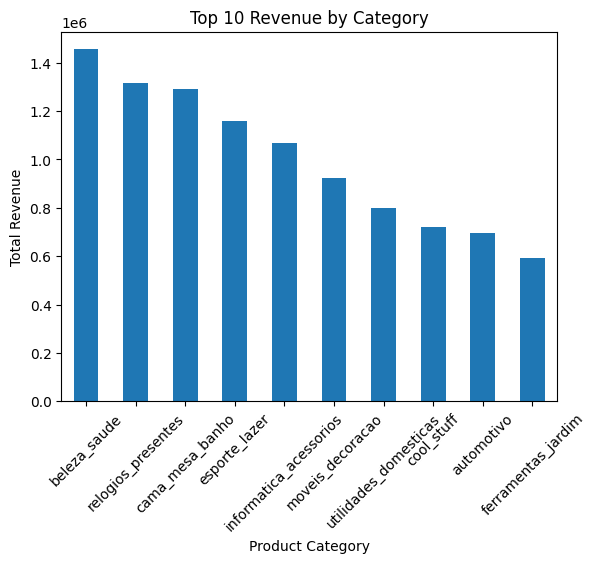

In [94]:
# VISUALISASI REVENUE PER CATEGORY
plt.figure()
category_revenue.head(10).plot(kind='bar')
plt.title("Top 10 Revenue by Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

Grafik menunjukkan bahwa kategori seperti beleza_saude, relogios_presentes, dan cama_mesa_banho memiliki kontribusi revenue tertinggi dibandingkan kategori lainnya.

Hal ini menunjukkan adanya dominasi kategori tertentu dalam menghasilkan pendapatan. Berdasarkan hasil EDA sebelumnya, revenue sangat dipengaruhi oleh price, sehingga tingginya kontribusi pada kategori tersebut kemungkinan berasal dari produk dengan harga lebih tinggi atau volume transaksi yang besar.

### Pertanyaan 2:

Visualisasi ini bertujuan untuk memahami distribusi pelanggan berdasarkan segmentasi RFM.

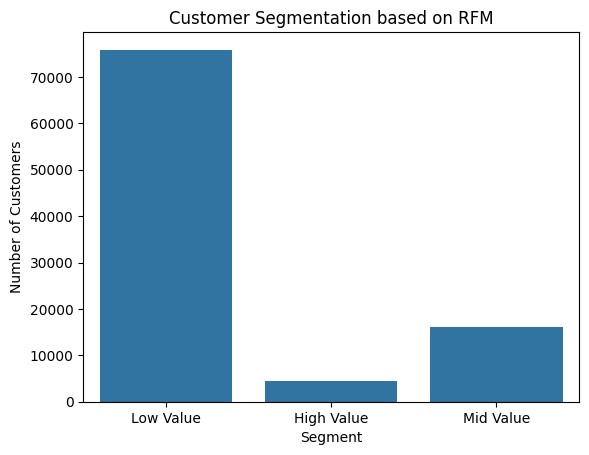

In [95]:
# Visualisasi RFM (Segmentasi)
plt.figure()
sns.countplot(x='segment', data=rfm)
plt.title("Customer Segmentation based on RFM")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

Grafik menunjukkan bahwa sebagian besar pelanggan berada pada segmen Low Value, sementara hanya sebagian kecil yang termasuk dalam segmen High Value.

Hal ini mengindikasikan bahwa sebagian besar pelanggan memiliki kontribusi transaksi yang rendah, namun terdapat kelompok kecil pelanggan bernilai tinggi yang berpotensi memberikan kontribusi signifikan terhadap revenue.

Sejalan dengan hasil EDA sebelumnya, revenue sangat dipengaruhi oleh price, sehingga pelanggan pada segmen High Value kemungkinan berasal dari transaksi dengan nilai yang lebih besar.

## Conclusion & Recommendation





- **Conclusion pertanyaan 1:
** Berdasarkan hasil analisis, kontribusi revenue tidak tersebar secara merata di seluruh kategori produk.
Kategori seperti "beleza_saude" dan "informatica_acessorios" terbukti memberikan kontribusi revenue tertinggi dibandingkan kategori lainnya. Hal ini menunjukkan bahwa kategori tersebut memiliki permintaan yang lebih tinggi dan menjadi sumber utama pendapatan perusahaan selama periode analisis.
Sebaliknya, kategori dengan kontribusi revenue yang lebih rendah menunjukkan bahwa permintaan terhadap produk pada kategori tersebut relatif lebih kecil. Oleh karena itu, perusahaan dapat mempertimbangkan untuk memfokuskan strategi bisnis pada kategori dengan performa tinggi, serta melakukan evaluasi terhadap kategori dengan kontribusi rendah untuk meningkatkan kinerjanya.
Hal ini menunjukkan bahwa kategori tersebut memiliki permintaan yang lebih tinggi dan menjadi sumber utama pendapatan perusahaan selama periode analisis. Sejalan dengan hasil EDA sebelumnya, revenue sangat dipengaruhi oleh price, sehingga kategori dengan kontribusi tinggi kemungkinan berasal dari produk dengan harga lebih tinggi atau volume transaksi yang besar.

- **Conclusion pertanyaan 2:**  Berdasarkan hasil segmentasi pelanggan menggunakan metode RFM, sebagian besar pelanggan berada pada segmen Low Value.
Hal ini menunjukkan bahwa mayoritas pelanggan memiliki nilai transaksi yang relatif kecil. Namun, terdapat sebagian kecil pelanggan yang termasuk dalam segmen High Value dengan nilai transaksi yang jauh lebih tinggi.
Dari sisi kontribusi terhadap revenue, pelanggan Low Value memberikan kontribusi yang signifikan karena jumlahnya yang besar, meskipun nilai transaksi per pelanggan relatif kecil. Sementara itu, pelanggan High Value memberikan kontribusi besar per individu, meskipun jumlahnya lebih sedikit.
Dengan demikian, dapat disimpulkan bahwa revenue perusahaan berasal dari kombinasi banyak pelanggan dengan transaksi kecil dan sedikit pelanggan dengan transaksi besar. Hal ini juga sejalan dengan hasil EDA, di mana revenue dipengaruhi oleh nilai transaksi, sehingga pelanggan High Value berperan penting dalam peningkatan pendapatan perusahaan.

**Rekomendasi Action Item:**


1. Fokus pada kategori dengan revenue tinggi  
Kategori seperti "beleza_saude" dan "informatica_acessorios" dapat dijadikan prioritas dalam strategi bisnis, seperti peningkatan stok, promosi, atau pengembangan produk untuk memaksimalkan pendapatan.

2. Evaluasi kategori dengan performa rendah  
Kategori dengan kontribusi revenue rendah perlu dianalisis lebih lanjut untuk mengetahui penyebabnya, seperti kurangnya permintaan atau strategi pemasaran yang belum optimal.

3. Pertahankan pelanggan High Value  
Pelanggan dengan nilai transaksi tinggi perlu dipertahankan melalui program loyalitas, seperti pemberian diskon khusus, reward, atau layanan eksklusif.

4. Tingkatkan nilai transaksi pelanggan Low Value  
Pelanggan Low Value dapat didorong untuk meningkatkan transaksi melalui strategi seperti bundling produk, promosi, atau penawaran khusus.

5. Optimalkan strategi berbasis segmentasi  
Dengan adanya segmentasi RFM, perusahaan dapat menerapkan strategi yang berbeda untuk setiap segmen pelanggan guna meningkatkan efektivitas pemasaran.

# Simpan hasil RFM ke CSV untuk dashboard


In [96]:
rfm.to_csv("main_data.csv", index=False)
category_revenue.reset_index().to_csv("category_revenue.csv", index=False)